<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_2_Question_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
img = cv2.imread('/content/dog.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

In [4]:
def create_highpass_mask(shape, cutoff, filter_type='ideal', order=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols, 2), np.float32)

    for i in range(rows):
        for j in range(cols):
            d = np.sqrt((i - crow)**2 + (j - ccol)**2)

            if filter_type == 'ideal':
                mask_value = 0 if d <= cutoff else 1
            elif filter_type == 'butterworth':
                mask_value = 1 / (1 + (cutoff / d)**(2 * order))
            elif filter_type == 'gaussian':
                mask_value = 1 - np.exp(-(d**2) / (2 * (cutoff**2)))
            else:
                raise ValueError("Unknown filter type")

            mask[i, j] = [mask_value, mask_value]

    return mask

In [5]:
def apply_highpass_filter(image, cutoff=30, filter_type='ideal', order=2):
    rows, cols = image.shape
    # DFT + Shift
    dft = cv2.dft(np.float32(image), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Create high-pass filter mask
    mask = create_highpass_mask(dft_shift.shape[:2], cutoff, filter_type, order)

    # Apply filter
    fshift = dft_shift * mask

    # Inverse shift and IDFT
    f_ishift = np.fft.ifftshift(fshift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Normalize for display
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img_back

In [6]:
ideal_highpass = apply_highpass_filter(img, cutoff=30, filter_type='ideal')
butterworth_highpass = apply_highpass_filter(img, cutoff=30, filter_type='butterworth', order=2)
gaussian_highpass = apply_highpass_filter(img, cutoff=30, filter_type='gaussian')


/tmp/ipython-input-3892168020.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  mask_value = 1 / (1 + (cutoff / d)**(2 * order))


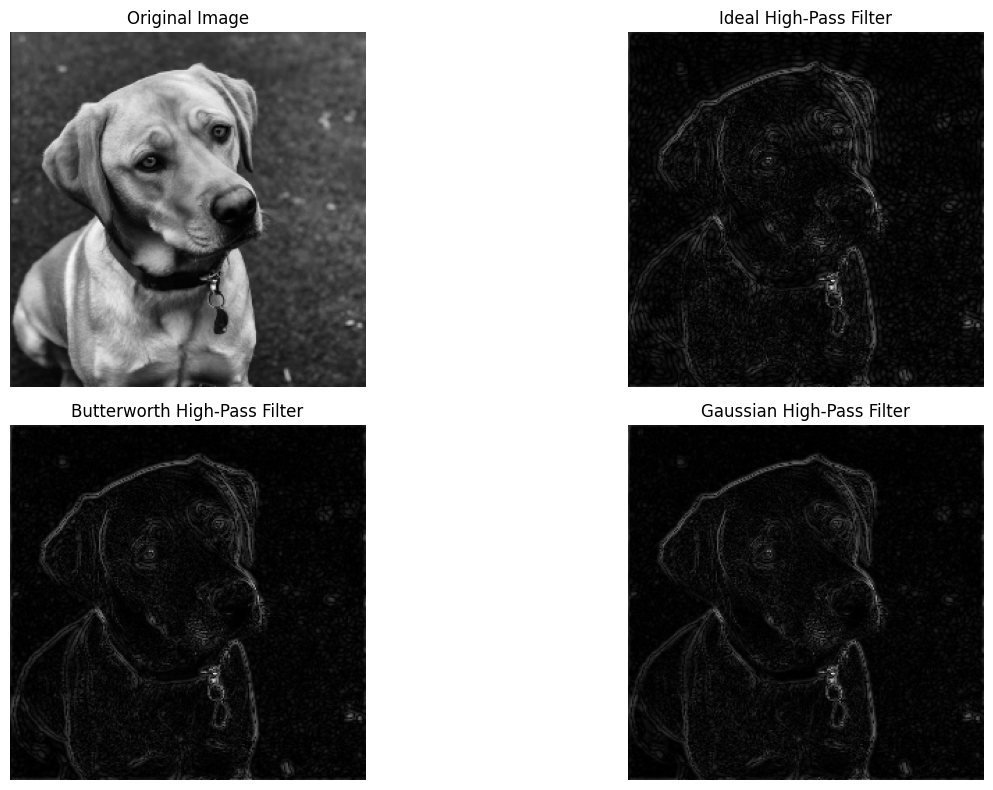

In [7]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(ideal_highpass, cmap='gray')
plt.title('Ideal High-Pass Filter')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(butterworth_highpass, cmap='gray')
plt.title('Butterworth High-Pass Filter')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gaussian_highpass, cmap='gray')
plt.title('Gaussian High-Pass Filter')
plt.axis('off')

plt.tight_layout()
plt.show()